<a href="https://colab.research.google.com/github/HawwaSherin/Sign-Language-CNN-M6-Assignment/blob/main/CNN_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Title: Sign Language Recognition using CNN**

This project focuses on building a deep learning model to recognize hand gestures representing letters in sign language. the dataset used is Sign Language MNIST dataset. It consists of graysacale images representing 24 alphabet classes (A-Y, excluding J and Z)
Main objectives:


*   build a baseline CNN
*   improve it with enhanced architectures

*   Compare and Evaluate them







**DATA LOADING**

In [1]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split

# Loading dataset
train = pd.read_csv('sign_mnist_train.csv')
test = pd.read_csv('sign_mnist_test.csv')

# Separate features and labels
X_train = train.drop('label', axis=1)
y_train = train['label']

X_test = test.drop('label', axis=1)
y_test = test['label']

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

Training shape: (27455, 784)
Test shape: (7172, 784)


**PREPROCESSING**

In [5]:
# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

y_train = y_train - 1
y_val = y_val - 1

# One-hot encoding
from tensorflow.keras.utils import to_categorical
import numpy as np

num_classes = len(np.unique(y_train))

y_train = to_categorical(y_train, num_classes=num_classes)
y_val = to_categorical(y_val, num_classes=num_classes)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)

Train: (14056, 28, 28, 1)
Validation: (3515, 28, 28, 1)




*   Reshaped images to 28x28 pixel format
*   Normalization is used to imrpove model performance
*   Validation set helps monitor overfitting






**BASELINE CNN MODEL**

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

num_classes = y_train.shape[1]

baseline_model = Sequential()

baseline_model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
baseline_model.add(MaxPooling2D((2,2)))

baseline_model.add(Conv2D(64, (3,3), activation='relu'))
baseline_model.add(MaxPooling2D((2,2)))

baseline_model.add(Flatten())

baseline_model.add(Dense(128, activation='relu'))
baseline_model.add(Dense(num_classes, activation='softmax'))

baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)



1.   Built a basic CNN Model with Conv2D and MaxPooling layers
2.   MaxPooling layer helps to extract features from images
3.   Flatten layer converts 2D features to 3D features
4.   Dense layer is usd for classification






**TRAINING BASELINE MODEL**

In [10]:
history_base = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64
)

Epoch 1/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 16s 62ms/step - accuracy: 0.4518 - loss: 1.8441 - val_accuracy: 0.7943 - val_loss: 0.7020
Epoch 2/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 20s 62ms/step - accuracy: 0.8618 - loss: 0.4718 - val_accuracy: 0.9366 - val_loss: 0.2537
Epoch 3/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 21s 64ms/step - accuracy: 0.9598 - loss: 0.1741 - val_accuracy: 0.9795 - val_loss: 0.1092
Epoch 4/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 14s 62ms/step - accuracy: 0.9895 - loss: 0.0671 - val_accuracy: 0.9989 - val_loss: 0.0367
Epoch 5/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 15s 67ms/step - accuracy: 0.9982 - loss: 0.0259 - val_accuracy: 0.9986 - val_loss: 0.0198
Epoch 6/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 14s 64ms/step - accuracy: 0.9998 - loss: 0.0119 - val_accuracy: 1.0000 - val_loss: 0.0100
Epoch 7/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 14s 62ms/step - accuracy: 0.9999 - loss: 0.0068 - val_accuracy: 0.9997 - val_loss: 0.0076
Epoch 8/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 14s 62ms/step - accuracy: 1.0000 - loss: 0.0044 - 

**ENHANCED MODEL- AlexNet-Style Model**

In [11]:
from tensorflow.keras.layers import Dropout

alex_model = Sequential()

alex_model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
alex_model.add(MaxPooling2D((2,2)))

alex_model.add(Conv2D(64, (3,3), activation='relu'))
alex_model.add(MaxPooling2D((2,2)))

alex_model.add(Conv2D(128, (3,3), activation='relu'))
alex_model.add(MaxPooling2D((2,2)))

alex_model.add(Flatten())

alex_model.add(Dense(128, activation='relu'))
alex_model.add(Dropout(0.5))

alex_model.add(Dense(num_classes, activation='softmax'))  # ✅ FIX

alex_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)



*   Added deeper layers
*   Dropout reduces overfitting
*   Improved earning capacity by addign more neurons



**TRAINING ENHANCED MODEL**

In [12]:
history_alex = alex_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64
)

Epoch 1/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 17s 68ms/step - accuracy: 0.1718 - loss: 2.7243 - val_accuracy: 0.4788 - val_loss: 1.7415
Epoch 2/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 15s 69ms/step - accuracy: 0.5233 - loss: 1.4274 - val_accuracy: 0.7781 - val_loss: 0.7596
Epoch 3/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 15s 68ms/step - accuracy: 0.7198 - loss: 0.8316 - val_accuracy: 0.8839 - val_loss: 0.4269
Epoch 4/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 15s 67ms/step - accuracy: 0.8054 - loss: 0.5664 - val_accuracy: 0.9007 - val_loss: 0.3095
Epoch 5/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 15s 67ms/step - accuracy: 0.8693 - loss: 0.3872 - val_accuracy: 0.9479 - val_loss: 0.1766
Epoch 6/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 15s 69ms/step - accuracy: 0.9097 - loss: 0.2679 - val_accuracy: 0.9741 - val_loss: 0.1122
Epoch 7/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 21s 70ms/step - accuracy: 0.9345 - loss: 0.2017 - val_accuracy: 0.9917 - val_loss: 0.0611
Epoch 8/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 15s 67ms/step - accuracy: 0.9519 - loss: 0.1524 - 

**RESULTS AND EVALUATION**

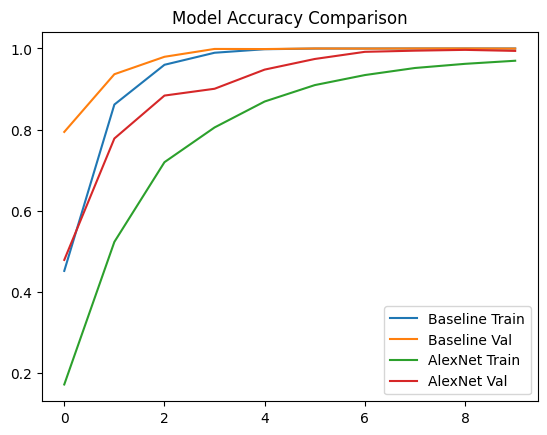

In [13]:
import matplotlib.pyplot as plt

plt.plot(history_base.history['accuracy'], label='Baseline Train')
plt.plot(history_base.history['val_accuracy'], label='Baseline Val')

plt.plot(history_alex.history['accuracy'], label='AlexNet Train')
plt.plot(history_alex.history['val_accuracy'], label='AlexNet Val')

plt.legend()
plt.title("Model Accuracy Comparison")
plt.show()